# WDBC Baseline and Noise Robustness Experiments

This notebook evaluates whether added noise-robustness mechanisms improve performance on the UCI WDBC dataset.
It compares results without robustness vs with robustness under feature-noise and label-noise settings.


## Setup
Run the next cell to import required libraries and create result/output folders.

In [22]:
import warnings
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC

plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

# Common experiment settings and output locations.
SEED = 42
DATA_PATH = Path("wdbc.data")
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# print(f"data pth from: {DATA_PATH.resolve()}")

## Data and Model Definitions
The next cell defines dataset loading, baseline and robust model presets, noise injection, and metric calculations used by following experiments.

In [23]:
MODEL_FACTORY = Callable[[], ClassifierMixin]

def build_feature_names() -> list[str]:
    base = [
        "radius",
        "texture",
        "perimeter",
        "area",
        "smoothness",
        "compactness",
        "concavity",
        "concave_points",
        "symmetry",
        "fractal_dimension",
    ]
    mean_names = [f"mean_{name}" for name in base]
    se_names = [f"se_{name}" for name in base]
    worst_names = [f"worst_{name}" for name in base]
    return ["id", "diagnosis", *mean_names, *se_names, *worst_names]

def load_wdbc(data_path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(data_path, header=None, names=build_feature_names())
    x = df.drop(columns=["id", "diagnosis"]).to_numpy(dtype=float)
    y = (df["diagnosis"] == "M").astype(int).to_numpy()
    return x, y

def build_model_registry(seed: int) -> dict[str, MODEL_FACTORY]:
    return {
        "logreg_baseline": lambda: Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        penalty="l2",
                        C=1.0,
                        solver="liblinear",
                        max_iter=2000,
                        random_state=seed,
                    ),
                ),
            ]
        ),
        "svm_rbf_baseline": lambda: Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVC(C=1.0, gamma="scale", probability=True, random_state=seed)),
            ]
        ),
        "rf_baseline": lambda: RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=seed,
            n_jobs=1,
        ),
        "logreg_robust": lambda: Pipeline(
            [
                ("scaler", RobustScaler()),
                (
                    "model",
                    LogisticRegression(
                        penalty="l2",
                        C=0.3,
                        solver="liblinear",
                        max_iter=2000,
                        random_state=seed,
                    ),
                ),
            ]
        ),
        "svm_rbf_robust": lambda: Pipeline(
            [
                ("scaler", RobustScaler()),
                ("model", SVC(C=0.8, gamma="scale", probability=True, random_state=seed)),
            ]
        ),
        "rf_robust": lambda: RandomForestClassifier(
            n_estimators=800,
            max_depth=None,
            min_samples_leaf=4,
            class_weight="balanced_subsample",
            random_state=seed,
            n_jobs=1,
        ),
    }

def add_feature_noise(
    x_train: np.ndarray,
    x_test: np.ndarray,
    alpha: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    if alpha <= 0:
        return x_train, x_test

    sigma = x_train.std(axis=0, ddof=0)
    train_noise = rng.normal(loc=0.0, scale=alpha * sigma, size=x_train.shape)
    test_noise = rng.normal(loc=0.0, scale=alpha * sigma, size=x_test.shape)
    return x_train + train_noise, x_test + test_noise

def flip_labels(y_train: np.ndarray, p: float, rng: np.random.Generator) -> tuple[np.ndarray, int]:
    if p <= 0:
        return y_train, 0

    y_noisy = y_train.copy()
    flip_mask = rng.random(y_train.shape[0]) < p
    y_noisy[flip_mask] = 1 - y_noisy[flip_mask]
    return y_noisy, int(flip_mask.sum())

def get_scores(model: ClassifierMixin, x_test: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x_test)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x_test)
    return y_pred.astype(float)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> dict[str, float]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_m": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_m": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity_b": specificity,
        "f1_m": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


#

## Robustness And Evaluation Utilities
The next cell adds preprocessing and weighting mechanisms, then evaluates each fold under controlled feature and label noise.

In [24]:
def clip_by_train_quantiles(
    x_train: np.ndarray,
    x_test: np.ndarray,
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> tuple[np.ndarray, np.ndarray]:
    lower = np.quantile(x_train, lower_q, axis=0)
    upper = np.quantile(x_train, upper_q, axis=0)

    return np.clip(x_train, lower, upper), np.clip(x_test, lower, upper)


def build_confidence_weights(
    x_train: np.ndarray,
    y_train: np.ndarray,
    seed: int,
    suspect_fraction: float = 0.05,
    down_weight: float = 0.35,
) -> tuple[np.ndarray, int]:
    if suspect_fraction <= 0:
        return np.ones(y_train.shape[0], dtype=float), 0

    splitter = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed)

    label_confidence = np.zeros(y_train.shape[0], dtype=float)

    for inner_train_idx, inner_val_idx in splitter.split(x_train, y_train):
        detector = Pipeline(
            [
                ("scaler", RobustScaler()),
                (
                    "model",
                    LogisticRegression(
                        penalty="l2",
                        C=0.3,
                        solver="liblinear",
                        max_iter=2000,
                        random_state=seed,
                    ),
                ),
            ]
        )
        detector.fit(x_train[inner_train_idx], y_train[inner_train_idx])
        prob_m = detector.predict_proba(x_train[inner_val_idx])[:, 1]
        p_label = np.where(y_train[inner_val_idx] == 1, prob_m, 1.0 - prob_m)
        label_confidence[inner_val_idx] = p_label

    suspect_count = int(np.round(suspect_fraction * y_train.shape[0]))
    suspect_count = int(np.clip(suspect_count, 1, y_train.shape[0]))

    suspect_idx = np.argpartition(label_confidence, suspect_count - 1)[:suspect_count]

    weights = np.ones(y_train.shape[0], dtype=float)
    weights[suspect_idx] = down_weight

    return weights, suspect_count


def evaluate_scenario(
    x: np.ndarray,
    y: np.ndarray,
    models: dict[str, MODEL_FACTORY],
    cv: RepeatedStratifiedKFold,
    feature_alpha: float,
    label_noise_p: float,
    base_seed: int,
    quantile_clip: bool = True,
    train_jitter_alpha: float = 0.02,
    confidence_weighting: bool = True,
    suspect_fraction: float = 0.05,
    down_weight: float = 0.35,
) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []

    for fold_index, (train_idx, test_idx) in enumerate(cv.split(x, y), start=1):
        x_train, x_test = x[train_idx], x[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        rng = np.random.default_rng(
            base_seed + fold_index * 1000 + int(feature_alpha * 1000) + int(label_noise_p * 10000)
        )

        x_train_work, x_test_work = x_train, x_test

        if quantile_clip:
            x_train_work, x_test_work = clip_by_train_quantiles(x_train_work, x_test_work)

        x_train_noisy, x_test_noisy = add_feature_noise(x_train_work, x_test_work, feature_alpha, rng)
        if train_jitter_alpha > 0:
            sigma = x_train_noisy.std(axis=0, ddof=0)
            jitter = rng.normal(loc=0.0, scale=train_jitter_alpha * sigma, size=x_train_noisy.shape)
            x_train_noisy = x_train_noisy + jitter

        y_train_noisy, flipped_count = flip_labels(y_train, label_noise_p, rng)

        sample_weight = None
        suspect_count = 0
        if confidence_weighting:

            sample_weight, suspect_count = build_confidence_weights(
                x_train_noisy,
                y_train_noisy,
                seed=base_seed + fold_index * 997,
                suspect_fraction=suspect_fraction,
                down_weight=down_weight,
            )

        for model_name, factory in models.items():
            model = factory()
            if sample_weight is None:
                model.fit(x_train_noisy, y_train_noisy)
            elif isinstance(model, Pipeline):
                try:
                    model.fit(x_train_noisy, y_train_noisy, model__sample_weight=sample_weight)
                except TypeError:
                    model.fit(x_train_noisy, y_train_noisy)

            else:
                try:
                    model.fit(x_train_noisy, y_train_noisy, sample_weight=sample_weight)
                except TypeError:
                    model.fit(x_train_noisy, y_train_noisy)

            y_pred = model.predict(x_test_noisy)
            y_score = get_scores(model, x_test_noisy, y_pred)
            metrics = compute_metrics(y_test, y_pred, y_score)

            rows.append(
                {
                    "model": model_name,
                    "fold": fold_index,
                    "feature_alpha": feature_alpha,
                    "label_noise_p": label_noise_p,
                    "flipped_labels": flipped_count,
                    "suspect_labels": suspect_count,
                    **metrics,
                }
            )

    return pd.DataFrame(rows)


def summarize_metrics(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = ["accuracy", "precision_m", "recall_m", "specificity_b", "f1_m", "roc_auc"]
    summary = df.groupby(group_cols, as_index=False)[metric_cols].agg(["mean", "std"])
    summary.columns = ["_".join(col).strip("_") for col in summary.columns.to_flat_index()]
    return summary.reset_index(drop=True)

def build_roc_auc_drop_table(clean_summary: pd.DataFrame, noisy_summary: pd.DataFrame, noise_col: str) -> pd.DataFrame:
    clean_map = clean_summary[["model", "roc_auc_mean"]].rename(columns={"roc_auc_mean": "roc_auc_clean"})
    merged = noisy_summary.merge(clean_map, on="model", how="left")
    merged["roc_auc_drop"] = merged["roc_auc_mean"] - merged["roc_auc_clean"]
    cols = ["model", noise_col, "roc_auc_clean", "roc_auc_mean", "roc_auc_drop"]

    return merged[cols].sort_values(["model", noise_col]).reset_index(drop=True)


def build_robustness_objective_table(
    clean_summary_df: pd.DataFrame,
    feature_summary_df: pd.DataFrame,
    label_summary_df: pd.DataFrame,
    lambda_penalty: float = 0.5,
    metric: str = "roc_auc",
) -> pd.DataFrame:
    metric_col = f"{metric}_mean"

    feature_noise = feature_summary_df.loc[feature_summary_df["feature_alpha"] > 0, ["model", metric_col]].copy()
    label_noise = label_summary_df.loc[label_summary_df["label_noise_p"] > 0, ["model", metric_col]].copy()

    stacked = pd.concat([feature_noise, label_noise], ignore_index=True)

    agg = stacked.groupby("model", as_index=False).agg(
        mean_noise_metric=(metric_col, "mean"),
        std_noise_metric=(metric_col, "std"),
    )
    agg["std_noise_metric"] = agg["std_noise_metric"].fillna(0.0)

    clean = clean_summary_df[["model", metric_col]].rename(columns={metric_col: "clean_metric"})

    table = clean.merge(agg, on="model", how="left")
    table["robust_score"] = table["mean_noise_metric"] - lambda_penalty * table["std_noise_metric"]
    table["avg_drop_vs_clean"] = table["mean_noise_metric"] - table["clean_metric"]

    return table.sort_values("robust_score", ascending=False).reset_index(drop=True)


## Run Comparison Experiments
The next cell runs the same protocol twice -> first without robustness mechanisms, then with them and then save gain focused tables.

In [25]:
# Load data and model presets.
X, y = load_wdbc(DATA_PATH)
models = build_model_registry(SEED)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED)

feature_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
label_levels = [0.0, 0.02, 0.05, 0.10, 0.15]

# Same protocol will executed twice- without vs with robustness mechanisms.
cfg_without = {
    "quantile_clip": False,
    "train_jitter_alpha": 0.0,
    "confidence_weighting": False,
    "suspect_fraction": 0.05,
    "down_weight": 0.35,
}

cfg_with = {
    "quantile_clip": True,
    "train_jitter_alpha": 0.02,
    "confidence_weighting": True,
    "suspect_fraction": 0.05,
    "down_weight": 0.35,
}


def run_flow(cfg: dict[str, float | bool]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Keeps splits and noise settings identical for a fair comparison.
    clean_summary_local = summarize_metrics(
        evaluate_scenario(
            X,
            y,
            models,
            cv,
            feature_alpha=0.0,
            label_noise_p=0.0,
            base_seed=SEED,
            **cfg,
        ),

        ["model"],
    )

    feature_summary_local = summarize_metrics(
        pd.concat(
            [
                evaluate_scenario(
                    X,
                    y,
                    models,
                    cv,
                    feature_alpha=alpha,
                    label_noise_p=0.0,
                    base_seed=SEED,
                    **cfg,
                )
                for alpha in feature_levels
            ],

            ignore_index=True,
        ),
        ["model", "feature_alpha"],
    )

    label_summary_local = summarize_metrics(
        pd.concat(
            [
                evaluate_scenario(
                    X,
                    y,
                    models,
                    cv,
                    feature_alpha=0.0,
                    label_noise_p=rate,
                    base_seed=SEED,
                    **cfg,
                )
                for rate in label_levels
            ],
            ignore_index=True,
        ),
        ["model", "label_noise_p"],
    )
    robustness_local = build_robustness_objective_table(
        clean_summary_local,
        feature_summary_local,
        label_summary_local,
        lambda_penalty=0.5,
        metric="roc_auc",
    )

    return clean_summary_local, feature_summary_local, label_summary_local, robustness_local


clean_summary_off, feature_summary_off, label_summary_off, robustness_table_off = run_flow(cfg_without)
clean_summary, feature_summary, label_summary, robustness_table = run_flow(cfg_with)

# print(f"Clean summary: {clean_summary.shape[0]} rows")
# print(f"Feature summary: {feature_summary.shape[0]} rows")
# print(f"Label summary: {label_summary.shape[0]} rows")


# Building compact gain tables for the research  objective.
gain_overall = pd.DataFrame(
    [
        {
            "metric": "clean_roc_auc_mean",
            "without_noise_robustness": clean_summary_off["roc_auc_mean"].mean(),
            "with_noise_robustness": clean_summary["roc_auc_mean"].mean(),
        },
        {
            "metric": "noise_roc_auc_mean",
            "without_noise_robustness": robustness_table_off["mean_noise_metric"].mean(),
            "with_noise_robustness": robustness_table["mean_noise_metric"].mean(),
        },
        {
            "metric": "robust_score_mean",
            "without_noise_robustness": robustness_table_off["robust_score"].mean(),
            "with_noise_robustness": robustness_table["robust_score"].mean(),
        },
    ]
)

gain_overall["gain_with_minus_without"] = (
    gain_overall["with_noise_robustness"] - gain_overall["without_noise_robustness"]
)

# print(f"Overall gain comparison: {gain_overall['gain_with_minus_without'].iloc[0]}")

gain_by_model = robustness_table_off[["model", "robust_score", "avg_drop_vs_clean"]].merge(
    robustness_table[["model", "robust_score", "avg_drop_vs_clean"]],
    on="model",
    suffixes=("_without", "_with"),
)

gain_by_model["robust_score_gain"] = gain_by_model["robust_score_with"] - gain_by_model["robust_score_without"]
gain_by_model["drop_reduction"] = gain_by_model["avg_drop_vs_clean_with"] - gain_by_model["avg_drop_vs_clean_without"]
gain_by_model = gain_by_model.sort_values("robust_score_gain", ascending=False).reset_index(drop=True)

# Save comparison focused outputs used in report and plots.
for file_name, df in {
    "clean_summary.csv": clean_summary,
    "feature_noise_summary.csv": feature_summary,
    "label_noise_summary.csv": label_summary,
    "robustness_objective_main_flow.csv": robustness_table,
    "robustness_objective_without_noise_robustness.csv": robustness_table_off,
    "comparison_gain_overall.csv": gain_overall,
    "comparison_gain_by_model.csv": gain_by_model,
}.items():
    df.to_csv(RESULTS_DIR / file_name, index=False)

print("Saved comparison focused outputs to:", RESULTS_DIR.resolve())

display(gain_overall)
display(gain_by_model[["model", "robust_score_without", "robust_score_with", "robust_score_gain"]])

# display(gain_by_model[["model", "avg_drop_vs_clean_without", "avg_drop_vs_clean_with", "drop_reduction"]])



d:\UOM\Intro to ML\Mini Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\UOM\Intro to ML\Mini Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\UOM\Intro to ML\Mini Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

Saved comparison focused outputs to: D:\UOM\Intro to ML\Mini Project\results


,metric,without_noise_robustness,with_noise_robustness,gain_with_minus_without
0,clean_roc_auc_mean,0.993517,0.994200,0.000684
1,noise_roc_auc_mean,0.991900,0.992914,0.001014
2,robust_score_mean,0.990405,0.991834,0.001428


,model,robust_score_without,robust_score_with,robust_score_gain
0,logreg_baseline,0.987658,0.991455,0.003797
1,logreg_robust,0.990910,0.993897,0.002986
2,svm_rbf_robust,0.993324,0.994662,0.001338
3,svm_rbf_baseline,0.993345,0.994541,0.001196
4,rf_robust,0.989094,0.989284,0.000190
5,rf_baseline,0.988102,0.987164,-0.000938


## Visualize Research Gains
The next cell plots three focused figures to show where robustness mechanisms improve or reduce performance.

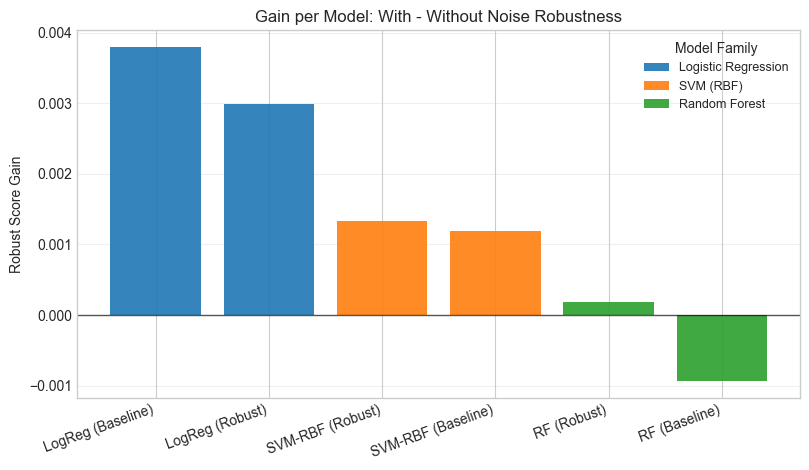

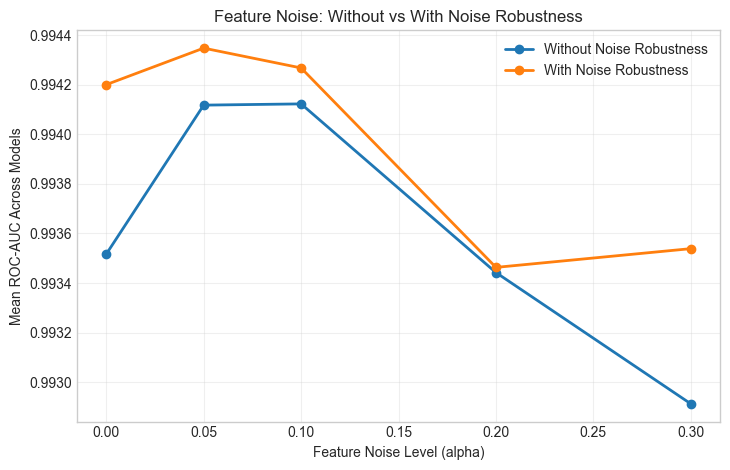

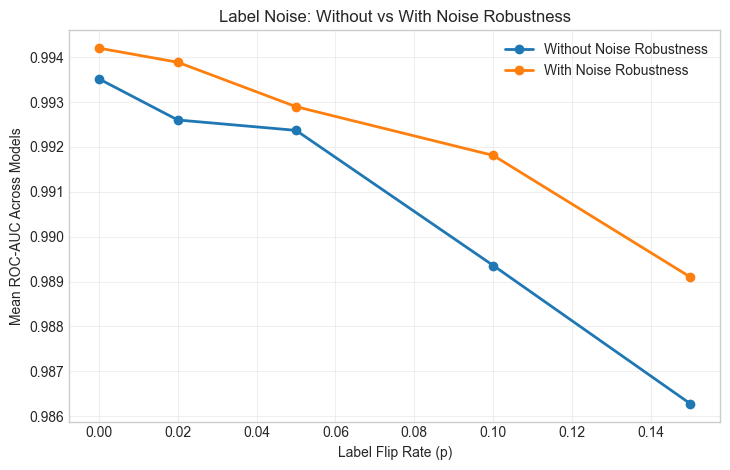

Saved comparison plots:
 - plots\research_gain_per_model.png
 - plots\research_gain_feature_noise.png
 - plots\research_gain_label_noise.png


In [26]:
MODEL_LABELS = {
    "logreg_baseline": "LogReg (Baseline)",
    "logreg_robust": "LogReg (Robust)",
    "svm_rbf_baseline": "SVM-RBF (Baseline)",
    "svm_rbf_robust": "SVM-RBF (Robust)",
    "rf_baseline": "RF (Baseline)",
    "rf_robust": "RF (Robust)",
}

FAMILY_COLORS = {"logreg": "#1f77b4", "svm": "#ff7f0e", "rf": "#2ca02c"}
FAMILY_LABELS = {
    "logreg": "Logistic Regression",
    "svm": "SVM (RBF)",
    "rf": "Random Forest",
}



def model_family(model_name: str) -> str:
    if model_name.startswith("logreg"):
        return "logreg"
    if model_name.startswith("svm"):
        return "svm"
    if model_name.startswith("rf"):
        return "rf"
    return "logreg"


def model_label(model_name: str) -> str:
    return MODEL_LABELS.get(model_name, model_name)

view = gain_by_model.sort_values("robust_score_gain", ascending=False).reset_index(drop=True)
feature_curve = feature_summary_off.groupby("feature_alpha", as_index=False)["roc_auc_mean"].mean()
feature_curve = feature_curve.rename(columns={"roc_auc_mean": "without"})
feature_curve["with"] = feature_summary.groupby("feature_alpha")["roc_auc_mean"].mean().to_numpy()

label_curve = label_summary_off.groupby("label_noise_p", as_index=False)["roc_auc_mean"].mean()
label_curve = label_curve.rename(columns={"roc_auc_mean": "without"})
label_curve["with"] = label_summary.groupby("label_noise_p")["roc_auc_mean"].mean().to_numpy()

saved_paths = []

# Figure 1: per model gain
fig, ax = plt.subplots(figsize=(8.2, 4.8))
x = np.arange(len(view))
bars = ax.bar(
    x,
    view["robust_score_gain"],
    color=[FAMILY_COLORS.get(model_family(m), "#1f77b4") for m in view["model"]],
    alpha=0.9,
)

ax.axhline(0.0, color="black", linewidth=1, alpha=0.65)
ax.set_xticks(x, [model_label(m) for m in view["model"]], rotation=20, ha="right")
ax.set_ylabel("Robust Score Gain")
ax.set_title("Gain per Model: With - Without Noise Robustness")
ax.grid(axis="y", alpha=0.3)

family_handles = {}

for bar, model_name in zip(bars, view["model"]):
    family = model_family(model_name)
    if family not in family_handles:
        family_handles[family] = bar
ax.legend(
    family_handles.values(),
    [FAMILY_LABELS[f] for f in family_handles.keys()],
    title="Model Family",
    fontsize=9,
)

out_path = PLOTS_DIR / "research_gain_per_model.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220)
plt.show()
plt.close(fig)

saved_paths.append(out_path)

# Figure 2: feature noise comparison
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(
    feature_curve["feature_alpha"],
    feature_curve["without"],
    marker="o",
    linewidth=2,
    label="Without Noise Robustness",
)


ax.plot(
    feature_curve["feature_alpha"],
    feature_curve["with"],
    marker="o",
    linewidth=2,
    label="With Noise Robustness",
)
ax.set_xlabel("Feature Noise Level (alpha)")
ax.set_ylabel("Mean ROC-AUC Across Models")

ax.set_title("Feature Noise: Without vs With Noise Robustness")
ax.grid(alpha=0.3)
ax.legend()

out_path = PLOTS_DIR / "research_gain_feature_noise.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220)
plt.show()
plt.close(fig)

saved_paths.append(out_path)

# Figure 3: label noise comparison
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(
    label_curve["label_noise_p"],
    label_curve["without"],
    marker="o",
    linewidth=2,
    label="Without Noise Robustness",
)
ax.plot(
    label_curve["label_noise_p"],
    label_curve["with"],
    marker="o",
    linewidth=2,
    label="With Noise Robustness",
)
ax.set_xlabel("Label Flip Rate (p)")
ax.set_ylabel("Mean ROC-AUC Across Models")

ax.set_title("Label Noise: Without vs With Noise Robustness")

ax.grid(alpha=0.3)

ax.legend()

out_path = PLOTS_DIR / "research_gain_label_noise.png"
fig.tight_layout()
fig.savefig(out_path, dpi=220)
plt.show()
plt.close(fig)

# save paths of generated plots for reporting
saved_paths.append(out_path)

print("Saved comparison plots:")
for p in saved_paths:
    print(" -", p)
